# AFM simulation and CNN


**This notebook provides a complete example on how to create a simulated AFM dataset and how to train a regression model for post-processing.**

The first section simulates a dataset. The second section builds and trains a model.

- **Output 1:** A simulated AFM dataset.
- **Output 2:** A trained model ready to process experimental data.


## 1. Optional installations

Uncomment the lines you need in a fresh environment.


In [1]:
!pip3 install deeplay plotly ipywidgets ipympl


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.7/176.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 132.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 28.7 MB/s eta 0:00:00


## 2. Imports and configuration

The defaults below are chosen so the notebook stays light enough for experimentation.
If you want the number of points per curve to be derived from the physical scan settings,
set `simulation_config.n_points_per_phase = None`.


In [72]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

torch.set_num_threads(1)

SEED = 72
np.random.seed(SEED)
torch.manual_seed(SEED)

Array = np.ndarray


@dataclass
class SimulationConfig:
    nx = 16
    ny = 16
    pixel_size_m = 2e-6
    z_length_m = 15e-6
    sampling_frequency_hz = 2048
    approach_rate_um_s = 2.0
    n_points_per_phase = 512
    tip_shape = "Sphere"
    include_thermal_noise = True
    noise_type = "Theoretical"
    experimental_noise_path = "thermal-noise-data_vDeflection_2025.11.28-16.29.33.tnd"


@dataclass
class DatasetConfig:
    n_train_samples = 18
    n_val_samples = 4
    n_test_samples = 3
    topography_types = ("gaussian_features", "hemisphere")
    substrate_stiffness_range_pa = (10e3, 20e3)
    feature_stiffness_range_pa = (1e3, 4e3)
    height_range_m = (1e-6, 6e-6)
    contact_point_range_m = (4.0e-6, 9.75e-6)  # within [0, z_length_m]

@dataclass
class ModelConfig:
    batch_size = 512
    learning_rate = 2e-3
    max_epochs = 12
    predict_contact_point = True
    cp_loss_weight = 0.1
    num_workers = 0
    use_padding = False
    input_representation = "approach_retract"
    accelerator = "auto"
    devices = 1
    default_sample_to_display = 0


simulation_config = SimulationConfig()
dataset_config = DatasetConfig()
model_config = ModelConfig()

print(f"GPU available: {torch.cuda.is_available()}")
print(simulation_config)
print(dataset_config)
print(model_config)


GPU available: True
SimulationConfig()
DatasetConfig()
ModelConfig()


## 3. Cantilever model with PSD


The `AFMCantilever` class represents the physical cantilever. Required inputs are: tip geometry, tip size, spring constant, resonance frequency, quality factor, and temperature — all available on the cantilever box or thermal calibration file.

The class handles two responsibilities: computing the contact area for a given indentation, and generating thermal noise. Three noise options are provided:

1. **Equipartition theorem** — RMS displacement from `k_B T / k`.
2. **Theoretical PSD** — damped harmonic oscillator spectrum.
3. **Experimental PSD** — loaded from your thermal calibration file.


In [48]:
class AFMCantilever:
    """AFM cantilever model with thermal-noise PSD support.

    Args:
        k: Spring constant in N/m.
        f0: Resonance frequency in Hz.
        Q: Quality factor.
        T: Temperature in kelvin.
    """

    def __init__(self, k=10, f0=7e3, Q=10.0, T=300.0):
        self.k = k
        self.f0 = f0
        self.Q = Q
        self.T = T
        self.kB = 1.380649e-23
        self.m_eff = k / (2.0 * np.pi * f0) ** 2
        self.gamma = 2.0 * np.pi * f0 * self.m_eff / Q
        self._experimental_psd_cache = {}
        self._grid_psd_cache = {}

    def thermal_noise_rms(self):
        """Return the RMS thermal deflection in meters."""
        return np.sqrt(self.kB * self.T / self.k)

    def thermal_noise_psd_theoretical(self, frequency_hz):
        """Return the one-sided theoretical displacement PSD.

        Args:
            frequency_hz: Frequency axis in hertz.

        Returns:
            One-sided displacement PSD in m^2/Hz.
        """
        omega = 2.0 * np.pi * frequency_hz
        omega0 = 2.0 * np.pi * self.f0
        denominator = (omega0**2 - omega**2) ** 2 + (omega * omega0 / self.Q) ** 2
        return (4.0 * self.kB * self.T * self.gamma) / (self.k**2 * denominator)

    def thermal_noise_psd_experimental(self, path):
        """Load and cache an experimental displacement PSD.

        Args:
            path: Path to the PSD text file.

        Returns:
            Tuple of (frequency_hz, spectral_density_x, spectral_density_x_fit).
        """
        cache_key = str(path)
        if cache_key not in self._experimental_psd_cache:
            data = np.loadtxt(path, skiprows=24)
            frequency_hz = data[:, 0]
            spectral_density_v = data[:, 1]
            spectral_density_v_fit = data[:, 3]
            with open(path, "r") as f:
                lines = f.readlines()
            for line in lines:
                if "sensitivity" in line:
                    volts_to_displacement_nm = float(line.split(":")[1].split()[0])
                if "parameter.f" in line:
                    self.f0 = float(line.split(":")[1].split()[0]) * 1e3
                    print(self.f0)
                if "parameter.Q" in line:
                    self.Q = float(line.split(":")[1].split()[0])
                    print(self.Q)
            displacement_scale_m = volts_to_displacement_nm * 1e-9
            spectral_density_x = spectral_density_v * displacement_scale_m**2
            spectral_density_x_fit = spectral_density_v_fit * displacement_scale_m**2
            self._experimental_psd_cache[cache_key] = (
                frequency_hz, spectral_density_x, spectral_density_x_fit
            )
        return self._experimental_psd_cache[cache_key]

    def get_noise_psd(
        self,
        n_points,
        sampling_frequency_hz,
        noise_type=simulation_config.noise_type,
        experimental_path=simulation_config.experimental_noise_path,
    ):
        """Return the simulation-grid PSD, reusing cached results when possible.

        Args:
            n_points: Number of time-domain samples.
            sampling_frequency_hz: Sampling frequency in Hz.
            noise_type: ``'Theoretical'`` or ``'Experimental'``.
            experimental_path: Path to experimental PSD file (required for
                ``noise_type='Experimental'``).

        Returns:
            Tuple of (frequency_hz, spectral_density_x).
        """
        cache_key = (
            noise_type.lower(),
            int(n_points),
            float(sampling_frequency_hz),
            None if experimental_path is None else str(experimental_path),
        )
        if cache_key in self._grid_psd_cache:
            return self._grid_psd_cache[cache_key]

        frequency_hz = np.fft.rfftfreq(n_points, d=1.0 / sampling_frequency_hz)
        if noise_type.lower() == "theoretical":
            spectral_density_x = self.thermal_noise_psd_theoretical(frequency_hz)
            frequency_raw_hz = frequency_hz
        elif noise_type.lower() == "experimental":
            if experimental_path is None:
                raise ValueError(
                    "`experimental_path` must be provided for experimental PSD noise."
                )
            frequency_raw_hz, spectral_density_raw, _ = (
                self.thermal_noise_psd_experimental(experimental_path)
            )
            interpolator = interp1d(
                frequency_raw_hz,
                spectral_density_raw,
                kind="linear",
                bounds_error=False,
                fill_value=(spectral_density_raw[0], spectral_density_raw[-1]),
            )
            spectral_density_x = interpolator(frequency_hz)
        else:
            raise ValueError(f"Unknown noise type: {noise_type}")

        self._grid_psd_cache[cache_key] = (frequency_hz, spectral_density_x)
        return self._grid_psd_cache[cache_key]

    def sample_thermal_noise(
        self,
        n_points,
        sampling_frequency_hz,
        noise_type=simulation_config.noise_type,
        experimental_path=simulation_config.experimental_noise_path,
        rng=None,
    ):
        """Draw one thermal-noise trace from a cached PSD using random phases."""
        return self.sample_thermal_noise_batch(
            n_curves=1,
            n_points=n_points,
            sampling_frequency_hz=sampling_frequency_hz,
            noise_type=noise_type,
            experimental_path=experimental_path,
            rng=rng,
        )[0]

    def sample_thermal_noise_batch(
        self,
        n_curves,
        n_points,
        sampling_frequency_hz,
        noise_type=simulation_config.noise_type,
        experimental_path=simulation_config.experimental_noise_path,
        rng=None,
    ):
        """Draw a batch of thermal-noise curves with shared PSD and random phases.

        The PSD is loaded or computed once. Each call draws new random phases
        to produce independent noise traces.

        Args:
            n_curves: Number of noise traces to generate.
            n_points: Number of time-domain samples per curve.
            sampling_frequency_hz: Sampling frequency in Hz.
            noise_type: ``'Theoretical'`` or ``'Experimental'``.
            experimental_path: Path to experimental PSD file.
            rng: Optional numpy random generator.

        Returns:
            Array of shape ``(n_curves, n_points)`` containing noise traces in meters.
        """
        rng = np.random.default_rng() if rng is None else rng
        frequency_hz, spectral_density_x = self.get_noise_psd(
            n_points=n_points,
            sampling_frequency_hz=sampling_frequency_hz,
            noise_type=noise_type,
            experimental_path=experimental_path,
        )
        frequency_step_hz = sampling_frequency_hz / n_points
        amplitude = n_points * np.sqrt(
            np.maximum(spectral_density_x * frequency_step_hz / 2.0, 0.0)
        )

        coefficients = np.zeros((n_curves, amplitude.shape[0]), dtype=np.complex128)
        if amplitude.shape[0] > 2:
            phase = rng.uniform(0.0, 2.0 * np.pi, size=(n_curves, amplitude.shape[0] - 2))
            coefficients[:, 1:-1] = amplitude[1:-1][None, :] * np.exp(1j * phase)

        coefficients[:, 0] = 0.0
        if n_points % 2 == 0 and amplitude.shape[0] > 1:
            nyquist_sign = np.sign(rng.standard_normal(n_curves))
            coefficients[:, -1] = amplitude[-1] * nyquist_sign

        noise_m = np.fft.irfft(coefficients, n=n_points, axis=-1)
        rms = self.thermal_noise_rms()
        scaling = np.std(noise_m) * 0.5 / rms
        return (noise_m / scaling).real


**Thermal noise from file**

Uncomment and run this cell if you wish to load an experimental thermal calibration file. When running locally, store the file in the folder with the script and make sure that the path is accessible.

In [11]:
from google.colab import files
import os

print("Upload your experimental PSD text file (e.g., .txt or .csv):")
uploaded = files.upload()
for filename in uploaded.keys():
     print(f'Uploaded "{filename}" ({len(uploaded[filename])} bytes)')
     simulation_config.experimental_noise_path = filename
     simulation_config.noise_type = "Experimental"


ModuleNotFoundError: No module named 'google.colab'

## 4. Contact mechanics


The `HertzContact` class transforms indentation depth into a force response. The Hertz model is provided as an example suited to biological applications. You can replace it with any contact model appropriate for your experiment.

In [49]:
class HertzContact:
    """Hertz contact model for spherical and pyramidal tips.

    Args:
        R: Tip radius in meters.
        nu: Poisson ratio of the sample.
        alpha: Pyramid face angle in degrees.
    """

    def __init__(self, R=10e-9, nu=0.5, alpha=18.0):
        self.R = R
        self.nu = nu
        self.alpha = alpha

    @property
    def alpha_rad(self):
        """Return the pyramid face angle in radians."""
        return np.deg2rad(self.alpha)

    def hertz_sphere(self, indentation_m, stiffness_pa):
        """Return the Hertz force for a spherical tip."""
        return (
            (4.0 / 3.0)
            * stiffness_pa
            * np.sqrt(self.R)
            * indentation_m**1.5
            / (1.0 - self.nu**2)
        )

    def hertz_cone(self, indentation_m, stiffness_pa):
        """Return the Hertz-like force for a conical approximation."""
        return (
            stiffness_pa
            * np.tan(self.alpha_rad)
            * indentation_m**2
            / (np.sqrt(2.0) * (1.0 - self.nu**2))
        )

    def force(self, cantilever_shape, indentation_m, stiffness_pa):
        """Return the contact force for the given indentation.

        Args:
            cantilever_shape: Tip geometry, either ``'Sphere'`` or ``'Pyramid'``.
            indentation_m: Indentation depth in meters.
            stiffness_pa: Young's modulus in pascal.

        Returns:
            Contact force in newtons.
        """
        indentation_safe_m = np.maximum(np.asarray(indentation_m, dtype=np.float64), 0.0)
        if cantilever_shape == "Sphere":
            return self.hertz_sphere(indentation_safe_m, stiffness_pa)
        if cantilever_shape == "Pyramid":
            return self.hertz_cone(indentation_safe_m, stiffness_pa)
        raise ValueError(f"Unsupported cantilever shape: {cantilever_shape}")


## 5. Synthetic sample-map generator


The `SampleGenerator` class builds a synthetic sample. You provide topography type and mechanical property ranges; the class returns a 2D topography map, a stiffness map, and a **contact point map**.

### Contact point convention

The contact point is defined as the **absolute z-position along the displacement axis** at which the tip first touches the sample surface. A large contact-point value means the tip is still far from the surface when first contact occurs (i.e., the approach has barely started). A small value means the tip nearly traverses the full scan range before touching.

Internally this is derived by inverting the topography: a tall feature sits closer to the tip and is therefore contacted earlier in the approach, giving a **larger** contact-point position.

  `contact_point_m = z_length_m - (offset from substrate)`


In [68]:
class SampleGenerator:
    """Generate topography, stiffness, and contact-point maps."""

    def __init__(
        self,
        substrate_stiffness_range_pa=(10e3, 20e3),
        feature_stiffness_range_pa=(1e3, 2e3),
        height_range_m=(1e-6, 4e-6),
        contact_point_range_m=(5.0e-6, 9.75e-6),
    ):
        self.substrate_stiffness_range_pa = substrate_stiffness_range_pa
        self.feature_stiffness_range_pa = feature_stiffness_range_pa
        self.height_range_m = height_range_m
        self.contact_point_range_m = contact_point_range_m

    def create_topography(self, size=(128, 128), pixel_size_m=1e-6,
                          topography_type="gaussian_features", rng=None):
        """Create one synthetic sample map.

        Args:
            size: Map dimensions as ``(ny, nx)`` in pixels.
            pixel_size_m: Physical size of one pixel in meters.
            topography_type: ``'gaussian_features'`` or ``'hemisphere'``.
            rng: Optional numpy random generator.

        Returns:
            Tuple of ``(topography_m, stiffness_map_pa, contact_point_map_m)``.
        """
        rng = np.random.default_rng() if rng is None else rng
        ny, nx = size
        topography_m = np.ones((ny, nx), dtype=np.float64)*1e-8
        stiffness_map_pa = rng.uniform(
            self.substrate_stiffness_range_pa[0],
            self.substrate_stiffness_range_pa[1],
            size=(ny, nx),
        )

        if topography_type == "gaussian_features":
            n_features = int(rng.integers(4, 10))
            y, x = np.ogrid[0:ny, 0:nx]
            for _ in range(n_features):
                cx = int(rng.integers(0, nx))
                cy = int(rng.integers(0, ny))
                amplitude = float(rng.uniform(*self.height_range_m))
                sigma_px = float(rng.uniform(3.0, 10.0))
                gaussian = amplitude * np.exp(
                    -((x - cx) ** 2 + (y - cy) ** 2) / (2.0 * sigma_px**2)
                )
                topography_m += gaussian

        elif topography_type == "hemisphere":
            radius_px = min(nx, ny) // 4
            cx, cy = nx // 2, ny // 2
            y, x = np.ogrid[:ny, :nx]
            r2 = (x - cx) ** 2 + (y - cy) ** 2
            mask = r2 <= radius_px**2
            topography_m[mask] = self.height_range_m[1] * np.sqrt(
                1.0 - r2[mask] / radius_px**2
            )
        else:
            raise ValueError(f"Unsupported topography type: {topography_type}")

        feature_mask = topography_m > np.percentile(topography_m, 70.0)
        stiffness_map_pa[feature_mask] = rng.uniform(
            self.feature_stiffness_range_pa[0],
            self.feature_stiffness_range_pa[1],
            size=int(feature_mask.sum()),
        )

        if float(topography_m.max()) > float(topography_m.min()):
            normalized_topography = (topography_m - topography_m.min()) / (
                topography_m.max() - topography_m.min()
            )
        else:
            normalized_topography = np.zeros_like(topography_m)
        
        cp_min, cp_max = self.contact_point_range_m
        contact_point_map_m = np.interp(
            normalized_topography,
            (0.0, 1.0),
            (cp_max, cp_min),
        )
        
        contact_point_map_m = np.clip(
            contact_point_map_m,
            self.contact_point_range_m[0],
            self.contact_point_range_m[1],
        )
        
        return topography_m, stiffness_map_pa, topography_m


## 6. AFM simulator


The `AFMSimulator` combines all previous classes into a vectorised map simulator. It returns 2D maps of force-distance curves, each with additive thermal noise.

In [69]:
class AFMSimulator:
    """Vectorized AFM curve simulator.

    Uses a single global displacement axis for all pixels. Pixel-to-pixel
    differences arise from the local stiffness and contact-point position.

    The displacement axis runs from 0 to ``z_length_m``. A pixel with contact-point
    position ``cp`` is touched by the tip when the displacement reaches ``cp``.

    Args:
        cantilever: An ``AFMCantilever`` instance.
        contact_model: A ``HertzContact`` instance.
        sample_generator: A ``SampleGenerator`` instance.
        config: A ``SimulationConfig`` instance.
    """

    def __init__(self, cantilever, contact_model, sample_generator, config):
        self.cantilever = cantilever
        self.contact_model = contact_model
        self.sample_generator = sample_generator
        self.config = config
        self.n_points_per_phase = self._compute_n_points_per_phase()
        self.n_points_total = 2 * self.n_points_per_phase
        self.displacement_axis_m = self._build_displacement_axis()

    def _compute_n_points_per_phase(self):
        """Compute or reuse the number of points for the approach branch."""
        if self.config.n_points_per_phase is not None:
            return int(self.config.n_points_per_phase)
        total_time_s = self.config.z_length_m / (self.config.approach_rate_um_s * 1e-6)
        return max(32, int(np.ceil(total_time_s * self.config.sampling_frequency_hz)))

    def _build_displacement_axis(self):
        """Build a shared approach+retract displacement axis in meters."""
        approach_m = np.linspace(
            0.0, self.config.z_length_m, self.n_points_per_phase, endpoint=False
        )
        retract_m = np.linspace(
            self.config.z_length_m, 0.0, self.n_points_per_phase
        )
        return np.concatenate([approach_m, retract_m]).astype(np.float64)

    def simulate_force_map(
        self,
        stiffness_map_pa,
        contact_point_map_m,
        include_thermal_noise=True,
        noise_type=simulation_config.noise_type,
        experimental_path=simulation_config.experimental_noise_path,
        rng=None,
    ):
        """Simulate a map of force curves.

        Args:
            stiffness_map_pa: Young's modulus map in pascal, shape ``(ny, nx)``.
            contact_point_map_m: Pixel-wise contact-point position map in meters,
                shape ``(ny, nx)``. Each value is the displacement-axis position
                at which the tip first touches that pixel.
            include_thermal_noise: Whether to add thermal noise.
            noise_type: ``'Theoretical'`` or ``'Experimental'``.
            experimental_path: Path to experimental PSD file.
            rng: Optional numpy random generator.

        Returns:
            Dictionary with keys: ``displacement_axis_m``, ``indentation_m``,
            ``force_n``, ``deflection_m``, ``thermal_noise_m``,
            ``measured_force_n``, ``measured_deflection_m``, ``contact_indices``.
        """
        rng = np.random.default_rng() if rng is None else rng

        displacement_axis_m = self.displacement_axis_m

        indentation_m = np.maximum(
            - displacement_axis_m[None, None, :] + contact_point_map_m[..., None],
            0.0,
        )

        force_n = self.contact_model.force(
            cantilever_shape=self.config.tip_shape,
            indentation_m=indentation_m,
            stiffness_pa=stiffness_map_pa[..., None],
        )

        deflection_m = force_n / self.cantilever.k

        thermal_noise_m = np.zeros_like(deflection_m)
        if include_thermal_noise:
            thermal_noise_m = self.cantilever.sample_thermal_noise_batch(
                n_curves=stiffness_map_pa.size,
                n_points=self.n_points_total,
                sampling_frequency_hz=self.config.sampling_frequency_hz,
                noise_type=noise_type,
                experimental_path=experimental_path,
                rng=rng,
            ).reshape(stiffness_map_pa.shape + (self.n_points_total,))

        measured_deflection_m = deflection_m + thermal_noise_m
        measured_force_n = measured_deflection_m * self.cantilever.k

        # Contact index: first index where displacement >= contact_point.
        contact_indices = np.searchsorted(
            self.displacement_axis_m[: self.n_points_per_phase],
            contact_point_map_m.ravel(),
            side="left",
        ).reshape(contact_point_map_m.shape)
        contact_indices = np.clip(contact_indices, 0, self.n_points_per_phase - 1)

        return {
            "displacement_axis_m": displacement_axis_m,
            "indentation_m": indentation_m,
            "force_n": force_n,
            "deflection_m": deflection_m,
            "thermal_noise_m": thermal_noise_m,
            "measured_force_n": measured_force_n,
            "measured_deflection_m": measured_deflection_m,
            "contact_indices": contact_indices,
        }


## 7. Plotting utilities


Helper functions for visualising simulator outputs.

In [70]:
def plot_maps(topography_m, stiffness_map_pa, contact_point_map_m):
    """Plot topography, stiffness, and contact-point maps side by side.

    Args:
        topography_m: 2D topography array in meters.
        stiffness_map_pa: 2D stiffness array in pascal.
        contact_point_map_m: 2D contact-point position array in meters.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    im0 = axes[0].imshow(topography_m * 1e6, cmap="viridis", aspect="equal")
    axes[0].set_title("Topography [µm]")
    axes[0].set_xlabel("X [pixel]")
    axes[0].set_ylabel("Y [pixel]")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(stiffness_map_pa / 1e3, cmap="magma", aspect="equal")
    axes[1].set_title("Stiffness [kPa]")
    axes[1].set_xlabel("X [pixel]")
    axes[1].set_ylabel("Y [pixel]")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    im2 = axes[2].imshow(contact_point_map_m * 1e6, cmap="cividis", aspect="equal")
    axes[2].set_title("Contact-point position [µm]")
    axes[2].set_xlabel("X [pixel]")
    axes[2].set_ylabel("Y [pixel]")
    plt.colorbar(im2, ax=axes[2], shrink=0.8)

    plt.tight_layout()
    plt.show()


def plot_force_curve(displacement_axis_m, force_n, title="Force curve"):
    """Plot approach and retract branches of one force curve.

    Args:
        displacement_axis_m: 1D displacement axis in meters (approach+retract).
        force_n: 1D force array in newtons (approach+retract).
        title: Plot title string.
    """
    n = displacement_axis_m.shape[0] // 2
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(displacement_axis_m[:n] * 1e6, force_n[:n] * 1e9, label="Approach")
    ax.plot(displacement_axis_m[n:] * 1e6, force_n[n:] * 1e9, label="Retract")
    ax.set_xlabel("Displacement [µm]")
    ax.set_ylabel("Force [nN]")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_psd(
    frequency_hz,
    spectral_density_m2_per_hz,
    cantilever,
    sampling_frequency,
    title="Displacement PSD",
):
    """Plot a square-root displacement PSD on log-log axes.

    Args:
        frequency_hz: Frequency axis in Hz.
        spectral_density_m2_per_hz: PSD values in m²/Hz.
        cantilever: An ``AFMCantilever`` used to mark the resonance frequency.
        sampling_frequency: Sampling frequency in Hz (used to mark the Nyquist limit).
        title: Plot title string.
    """
    fig, ax = plt.subplots(figsize=(7, 4))
    stop = np.where(frequency_hz >= sampling_frequency)[0][0]
    ax.loglog(frequency_hz / 1e3, np.sqrt(spectral_density_m2_per_hz), linewidth=2.0,
              label="Full PSD")
    ax.loglog(frequency_hz[:stop] / 1e3, np.sqrt(spectral_density_m2_per_hz)[:stop],
              linewidth=2.0, label="Within sampling bandwidth")
    ax.axvline(cantilever.f0 / 1e3, color="red", linestyle="--",
               label=f"f0 = {cantilever.f0 / 1e3:.1f} kHz")
    ax.set_xlabel("Frequency [kHz]")
    ax.set_ylabel("Sqrt(PSD) [m / sqrt(Hz)]")
    ax.set_title(title)
    ax.grid(alpha=0.3, which="both")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 8. Instantiate the simulator and generate one example sample


We use the simulator to generate data and visualise it with the functions defined above.

Curve shape per sample map = (16, 16, 1024)
N_points_per_phase = 512


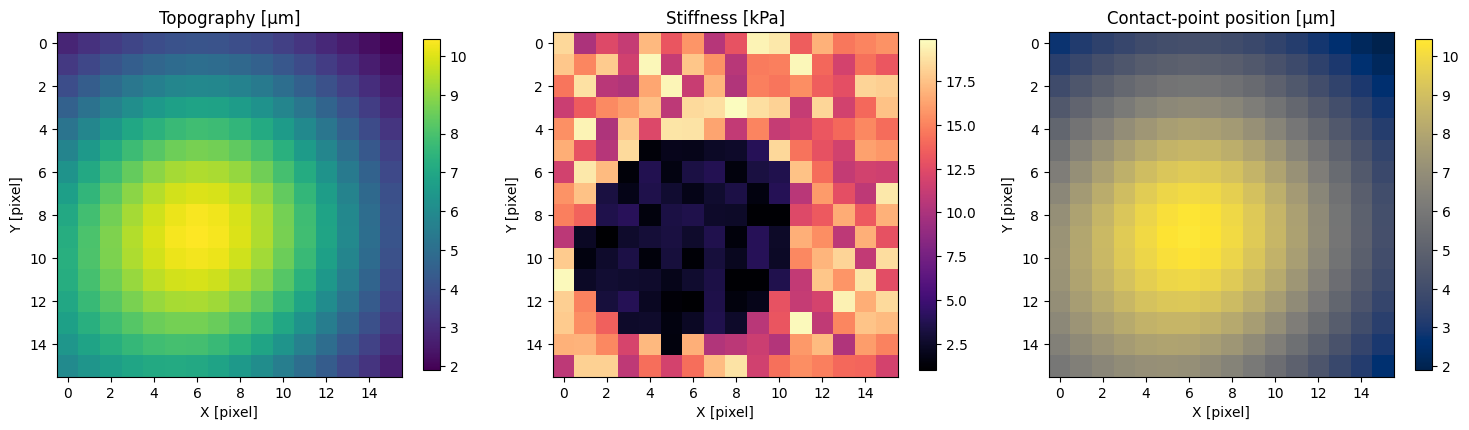

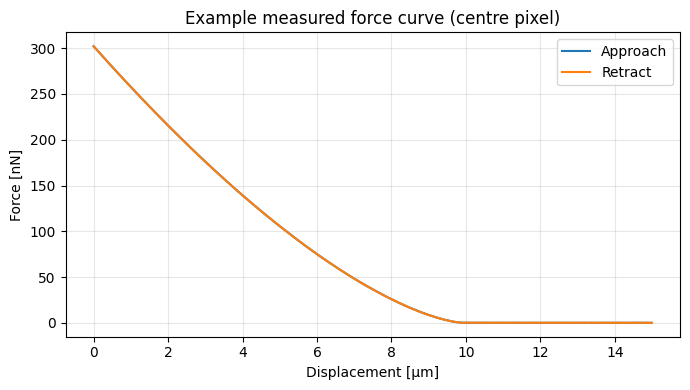

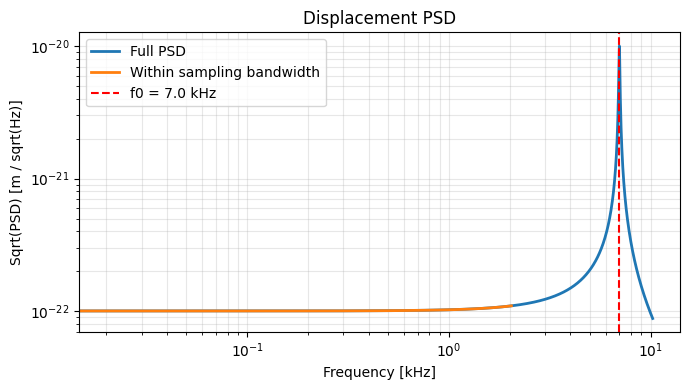

In [73]:
rng = np.random.default_rng(SEED)

cantilever = AFMCantilever(k=0.1, f0=7e3, Q=100.0, T=300.0)
contact_model = HertzContact(R=5e-6, nu=0.5, alpha=18.0)
sample_generator = SampleGenerator(
    substrate_stiffness_range_pa=dataset_config.substrate_stiffness_range_pa,
    feature_stiffness_range_pa=dataset_config.feature_stiffness_range_pa,
    height_range_m=dataset_config.height_range_m,
    contact_point_range_m=dataset_config.contact_point_range_m,
)
simulator = AFMSimulator(
    cantilever=cantilever,
    contact_model=contact_model,
    sample_generator=sample_generator,
    config=simulation_config,
)

print(f"Curve shape per sample map = "
      f"({simulation_config.ny}, {simulation_config.nx}, {simulator.n_points_total})")
print(f"N_points_per_phase = {simulator.n_points_per_phase}")

example_topography_m, example_stiffness_pa, example_contact_point_m = (
    sample_generator.create_topography(
        size=(simulation_config.ny, simulation_config.nx),
        pixel_size_m=simulation_config.pixel_size_m,
        topography_type="gaussian_features",
        rng=rng,
    )
)

example_output = simulator.simulate_force_map(
    stiffness_map_pa=example_stiffness_pa,
    contact_point_map_m=example_contact_point_m,
    include_thermal_noise=simulation_config.include_thermal_noise,
    rng=rng,
)

plot_maps(example_topography_m, example_stiffness_pa, example_contact_point_m)

plot_force_curve(
    example_output["displacement_axis_m"],
    example_output["measured_force_n"][
        simulation_config.ny // 2, simulation_config.nx // 2
    ],
    title="Example measured force curve (centre pixel)",
)

frequency_hz, spectral_density_m2_per_hz = cantilever.get_noise_psd(
    n_points=simulator.n_points_total,
    sampling_frequency_hz=simulation_config.sampling_frequency_hz*10,
    noise_type=simulation_config.noise_type,
    experimental_path=simulation_config.experimental_noise_path,
)
plot_psd(
    frequency_hz,
    spectral_density_m2_per_hz,
    cantilever,
    sampling_frequency=simulation_config.sampling_frequency_hz,
)


## 9. Convert force curves into ML inputs

In [58]:
def build_force_inputs(measured_force_curves_nN, contact_indices, use_padding=False):
    """Create force-curve inputs for machine learning.

    Args:
        measured_force_curves_nN: Force curves, shape ``(n_samples, ny, nx, n_total)``
            in nanoNewtons.
        contact_indices: Integer contact indices, shape ``(n_samples, ny, nx)``.
        use_padding: If ``True``, build contact-only padded curves starting from the
            contact index. If ``False``, keep the full approach+retract curves.

        Returns:
            Dictionary with keys ``raw_force_nN``, ``valid_mask``,
            ``phase_channel``, and ``valid_lengths``.
    """
    n_samples, ny, nx, n_points_total = measured_force_curves_nN.shape
    n_points_per_phase = n_points_total // 2

    if not use_padding:
        raw_force_nN = measured_force_curves_nN.astype(np.float32).copy()
        valid_mask = np.ones_like(raw_force_nN, dtype=np.float32)
        phase_channel = np.ones_like(raw_force_nN, dtype=np.float32)
        phase_channel[..., :n_points_per_phase] = -1.0
        valid_lengths = np.full((n_samples, ny, nx), n_points_total, dtype=np.int32)
        return {
            "raw_force_nN": raw_force_nN,
            "valid_mask": valid_mask,
            "phase_channel": phase_channel,
            "valid_lengths": valid_lengths,
        }
    raw_force_nN = np.zeros_like(measured_force_curves_nN, dtype=np.float32)
    valid_mask = np.zeros_like(measured_force_curves_nN, dtype=np.float32)
    phase_channel = np.zeros_like(measured_force_curves_nN, dtype=np.float32)
    valid_lengths = np.zeros((n_samples, ny, nx), dtype=np.int32)

    for s in range(n_samples):
        for r in range(ny):
            for c in range(nx):
                start = int(contact_indices[s, r, c])
                approach = measured_force_curves_nN[s, r, c, :n_points_per_phase]
                retract = measured_force_curves_nN[s, r, c, n_points_per_phase:]
                seg_a = approach[start:]
                seg_r = retract[: n_points_per_phase - start]
                merged = np.concatenate([seg_a, seg_r])
                length = merged.shape[0]
                raw_force_nN[s, r, c, :length] = merged
                valid_mask[s, r, c, :length] = 1.0
                phase_channel[s, r, c, : seg_a.shape[0]] = -1.0
                phase_channel[s, r, c, seg_a.shape[0]:length] = 1.0
                valid_lengths[s, r, c] = length

    return {
        "raw_force_nN": raw_force_nN,
        "valid_mask": valid_mask,
        "phase_channel": phase_channel,
        "valid_lengths": valid_lengths,
    }


def compute_force_normalization(raw_force_nN, valid_mask):
    """Compute global normalization statistics from valid training points only.

    Args:
        raw_force_nN: Raw force array.
        valid_mask: Boolean/float mask with 1 where data is valid.

    Returns:
        Dictionary with ``force_mean_nN`` and ``force_std_nN``.
    """
    valid_values = raw_force_nN[valid_mask > 0.5]
    return {
        "force_mean_nN": float(valid_values.mean()),
        "force_std_nN": float(valid_values.std() + 1e-6),
    }


def normalize_force_channel(raw_force_nN, valid_mask, normalization_stats):
    """Normalize the force channel with global training-set statistics.

    Args:
        raw_force_nN: Raw force array.
        valid_mask: Mask array (1 = valid, 0 = padded).
        normalization_stats: Dictionary from ``compute_force_normalization``.

    Returns:
        Normalized force array as float32, with padded positions set to zero.
    """
    normalized = (
        raw_force_nN - normalization_stats["force_mean_nN"]
    ) / normalization_stats["force_std_nN"]
    normalized *= valid_mask
    return normalized.astype(np.float32)


def flatten_sample_axes(input_tensor, stiffness_maps_kpa, contact_point_maps_nm):
    """Flatten ``(n_samples, ny, nx, ...)`` arrays into a curve-wise dataset.

    Args:
        input_tensor: Array of shape ``(n_samples, ny, nx, n_channels, n_sequence)``.
        stiffness_maps_kpa: Stiffness map array in kPa.
        contact_point_maps_nm: Contact-point position map in nm.

    Returns:
        Dictionary with flattened ``curve_inputs``, ``stiffness_targets_kpa``,
        ``contact_point_targets_nm``, and index arrays.
    """
    n_samples, ny, nx, n_channels, n_sequence = input_tensor.shape

    si = np.repeat(np.arange(n_samples)[:, None, None], ny, axis=1)
    si = np.repeat(si, nx, axis=2)
    ri = np.repeat(np.arange(ny)[None, :, None], n_samples, axis=0)
    ri = np.repeat(ri, nx, axis=2)
    ci = np.repeat(np.arange(nx)[None, None, :], n_samples, axis=0)
    ci = np.repeat(ci, ny, axis=1)

    return {
        "curve_inputs": input_tensor.reshape(n_samples * ny * nx, n_channels, n_sequence),
        "stiffness_targets_kpa": stiffness_maps_kpa.reshape(-1),
        "contact_point_targets_nm": contact_point_maps_nm.reshape(-1),
        "sample_indices": si.reshape(-1),
        "row_indices": ri.reshape(-1),
        "col_indices": ci.reshape(-1),
    }


## 10. Generate train / validation / test sample sets

The split is done at the **sample-map level** to avoid train/test leakage between neighbouring pixels from the same synthetic sample.


In [59]:
def generate_sample_collection(n_samples, simulator, sample_generator, dataset_config, seed):
    """Generate a collection of synthetic AFM sample maps and force curves.

    Args:
        n_samples: Number of independent sample maps to generate.
        simulator: An ``AFMSimulator`` instance.
        sample_generator: A ``SampleGenerator`` instance.
        dataset_config: A ``DatasetConfig`` instance.
        seed: Integer seed for reproducible generation.

    Returns:
        Dictionary with topography, stiffness, contact-point, force-curve arrays,
        contact indices, and the displacement axis.
    """
    rng = np.random.default_rng(seed)
    ny = simulator.config.ny
    nx = simulator.config.nx
    n_points_total = simulator.n_points_total

    topography_maps_nm = np.zeros((n_samples, ny, nx), dtype=np.float32)
    stiffness_maps_kpa = np.zeros((n_samples, ny, nx), dtype=np.float32)
    contact_point_maps_nm = np.zeros((n_samples, ny, nx), dtype=np.float32)
    measured_force_curves_nN = np.zeros((n_samples, ny, nx, n_points_total), dtype=np.float32)
    contact_indices = np.zeros((n_samples, ny, nx), dtype=np.int32)

    for i in range(n_samples):
        topography_m, stiffness_pa, contact_point_m = sample_generator.create_topography(
            size=(ny, nx),
            pixel_size_m=simulator.config.pixel_size_m,
            topography_type="gaussian_features",
            rng=rng,
        )
        output = simulator.simulate_force_map(
            stiffness_map_pa=stiffness_pa,
            contact_point_map_m=contact_point_m,
            include_thermal_noise=simulator.config.include_thermal_noise,
            noise_type=simulator.config.noise_type,
            experimental_path=simulator.config.experimental_noise_path,
            rng=rng,
        )
        topography_maps_nm[i] = topography_m * 1e9
        stiffness_maps_kpa[i] = stiffness_pa / 1e3
        contact_point_maps_nm[i] = contact_point_m * 1e9
        measured_force_curves_nN[i] = output["measured_force_n"] * 1e9
        contact_indices[i] = output["contact_indices"]

    return {
        "topography_maps_nm": topography_maps_nm,
        "stiffness_maps_kpa": stiffness_maps_kpa,
        "contact_point_maps_nm": contact_point_maps_nm,
        "measured_force_curves_nN": measured_force_curves_nN,
        "contact_indices": contact_indices,
        "displacement_axis_um": simulator.displacement_axis_m * 1e6,
    }


train_collection = generate_sample_collection(
    n_samples=dataset_config.n_train_samples,
    simulator=simulator,
    sample_generator=sample_generator,
    dataset_config=dataset_config,
    seed=SEED + 10,
)
val_collection = generate_sample_collection(
    n_samples=dataset_config.n_val_samples,
    simulator=simulator,
    sample_generator=sample_generator,
    dataset_config=dataset_config,
    seed=SEED + 20,
)
test_collection = generate_sample_collection(
    n_samples=dataset_config.n_test_samples,
    simulator=simulator,
    sample_generator=sample_generator,
    dataset_config=dataset_config,
    seed=SEED + 30,
)

train_force_inputs = build_force_inputs(
    measured_force_curves_nN=train_collection["measured_force_curves_nN"],
    contact_indices=train_collection["contact_indices"],
    use_padding=model_config.use_padding,
)
val_force_inputs = build_force_inputs(
    measured_force_curves_nN=val_collection["measured_force_curves_nN"],
    contact_indices=val_collection["contact_indices"],
    use_padding=model_config.use_padding,
)
test_force_inputs = build_force_inputs(
    measured_force_curves_nN=test_collection["measured_force_curves_nN"],
    contact_indices=test_collection["contact_indices"],
    use_padding=model_config.use_padding,
)

normalization_stats = compute_force_normalization(
    raw_force_nN=train_force_inputs["raw_force_nN"],
    valid_mask=train_force_inputs["valid_mask"],
)

train_force_normalized = normalize_force_channel(
    raw_force_nN=train_force_inputs["raw_force_nN"],
    valid_mask=train_force_inputs["valid_mask"],
    normalization_stats=normalization_stats,
)
val_force_normalized = normalize_force_channel(
    raw_force_nN=val_force_inputs["raw_force_nN"],
    valid_mask=val_force_inputs["valid_mask"],
    normalization_stats=normalization_stats,
)
test_force_normalized = normalize_force_channel(
    raw_force_nN=test_force_inputs["raw_force_nN"],
    valid_mask=test_force_inputs["valid_mask"],
    normalization_stats=normalization_stats,
)

def _stack_inputs(force_normalized, force_inputs):
    return np.stack(
        [force_normalized, force_inputs["valid_mask"], force_inputs["phase_channel"]],
        axis=3,
    ).astype(np.float32)

train_input_tensor = _stack_inputs(train_force_normalized, train_force_inputs)
val_input_tensor   = _stack_inputs(val_force_normalized, val_force_inputs)
test_input_tensor  = _stack_inputs(test_force_normalized, test_force_inputs)

train_flat = flatten_sample_axes(
    input_tensor=train_input_tensor,
    stiffness_maps_kpa=train_collection["stiffness_maps_kpa"],
    contact_point_maps_nm=train_collection["contact_point_maps_nm"],
)
val_flat = flatten_sample_axes(
    input_tensor=val_input_tensor,
    stiffness_maps_kpa=val_collection["stiffness_maps_kpa"],
    contact_point_maps_nm=val_collection["contact_point_maps_nm"],
)
test_flat = flatten_sample_axes(
    input_tensor=test_input_tensor,
    stiffness_maps_kpa=test_collection["stiffness_maps_kpa"],
    contact_point_maps_nm=test_collection["contact_point_maps_nm"],
)

print("Padding enabled:", model_config.use_padding)
print("Train input shape:", train_flat["curve_inputs"].shape)
print("Validation input shape:", val_flat["curve_inputs"].shape)
print("Test input shape:", test_flat["curve_inputs"].shape)
print("Normalization stats:", normalization_stats)


Padding enabled: False
Train input shape: (4608, 3, 1024)
Validation input shape: (1024, 3, 1024)
Test input shape: (768, 3, 1024)
Normalization stats: {'force_mean_nN': 721.2665405273438, 'force_std_nN': 916.0081787109375}


## 11. Dataset wrappers


In [60]:
class AFMCurveDataset(Dataset):
    """Curve-wise PyTorch dataset for AFM regression.

    Args:
        curve_inputs: Input array of shape ``(n_curves, n_channels, n_sequence)``.
        stiffness_targets_kpa: Stiffness targets in kPa, shape ``(n_curves,)``.
        contact_point_targets_nm: Contact-point targets in nm, shape ``(n_curves,)``.
        predict_contact_point: If ``True``, the target tensor contains both stiffness
            and contact-point position concatenated along dim 0.
    """

    def __init__(
        self, curve_inputs, stiffness_targets_kpa, contact_point_targets_nm,
        predict_contact_point=False,
    ):
        self.curve_inputs = torch.tensor(curve_inputs, dtype=torch.float32)
        self.stiffness_targets_kpa = torch.tensor(
            stiffness_targets_kpa[:, None], dtype=torch.float32
        )
        self.contact_point_targets_nm = torch.tensor(
            contact_point_targets_nm[:, None], dtype=torch.float32
        )
        self.predict_contact_point = predict_contact_point

    def __len__(self):
        return int(self.curve_inputs.shape[0])

    def __getitem__(self, index):
        x = self.curve_inputs[index]
        if self.predict_contact_point:
            target = torch.cat(
                [self.stiffness_targets_kpa[index], self.contact_point_targets_nm[index]],
                dim=0,
            )
        else:
            target = self.stiffness_targets_kpa[index]
        return x, target


def make_datasets_and_loaders(
    train_flat, val_flat, test_flat, model_config
):
    """Build AFMCurveDataset objects and DataLoader objects for all splits.

    Args:
        train_flat: Flattened training collection from ``flatten_sample_axes``.
        val_flat: Flattened validation collection.
        test_flat: Flattened test collection.
        model_config: A ``ModelConfig`` instance.

    Returns:
        Tuple of (train_dataset, val_dataset, test_dataset,
        train_dataloader, val_dataloader, test_dataloader).
    """
    def _dataset(flat):
        return AFMCurveDataset(
            curve_inputs=flat["curve_inputs"],
            stiffness_targets_kpa=flat["stiffness_targets_kpa"],
            contact_point_targets_nm=flat["contact_point_targets_nm"],
            predict_contact_point=model_config.predict_contact_point,
        )

    def _loader(ds, shuffle):
        return DataLoader(
            ds,
            batch_size=model_config.batch_size,
            shuffle=shuffle,
            num_workers=model_config.num_workers,
        )

    train_ds = _dataset(train_flat)
    val_ds   = _dataset(val_flat)
    test_ds  = _dataset(test_flat)
    return (
        train_ds, val_ds, test_ds,
        _loader(train_ds, shuffle=True),
        _loader(val_ds, shuffle=False),
        _loader(test_ds, shuffle=False),
    )


(
    train_dataset, val_dataset, test_dataset,
    train_dataloader, val_dataloader, test_dataloader,
) = make_datasets_and_loaders(train_flat, val_flat, test_flat, model_config)


## 12. 1D CNN model (MSE Version)

In [61]:
class AFMCurveCNN(nn.Module):
    """1D CNN for AFM force-curve regression."""

    def __init__(self, in_channels=3, hidden_channels=(16, 32, 64),
                 predict_contact_point=False):
        super().__init__()
        self.predict_contact_point = predict_contact_point

        self.backbone = nn.Sequential(
            nn.Conv1d(in_channels, hidden_channels[0], kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_channels[0]),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(hidden_channels[0], hidden_channels[1], kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels[1]),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(hidden_channels[1], hidden_channels[2], kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels[2]),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)
        out_features = 2 if predict_contact_point else 1
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels[2], 64),
            nn.ReLU(),
            nn.Linear(64, out_features),
        )

    def forward(self, x):
        features = self.pool(self.backbone(x))
        return self.head(features)

## 13. Deeplay application


In [62]:
import deeplay as dl
from deeplay.applications import Application
from deeplay.external import Adam
import torchmetrics as tm

print("Deeplay imported successfully.")


class AFMStiffnessRegressor(Application):
    """Deeplay application for AFM regression using MSE loss."""

    def __init__(
        self,
        model,
        learning_rate=1e-3,
        predict_contact_point=False,
        cp_loss_weight=1.0,
        metrics=None,
        **kwargs
    ):
        if metrics is None:
            metrics = [tm.MeanSquaredError(), tm.MeanAbsoluteError()]

        super().__init__(
            loss=nn.MSELoss(),
            optimizer=Adam(lr=learning_rate),
            metrics=metrics,
            **kwargs,
        )
        self.model = model
        self.predict_contact_point = predict_contact_point
        self.cp_loss_weight = cp_loss_weight

    def forward(self, x):
        return self.model(x)

    def compute_loss(self, y_hat, y):
        """Standard MSE loss calculation."""
        if not self.predict_contact_point:
            return self.loss(y_hat, y.float())

        stiffness_hat, cp_hat = y_hat[:, :1], y_hat[:, 1:2]
        stiffness_true, cp_true = y[:, :1].float(), y[:, 1:2].float()

        stiffness_loss = self.loss(stiffness_hat, stiffness_true)
        cp_loss = self.loss(cp_hat, cp_true)

        return stiffness_loss + self.cp_loss_weight * cp_loss

Deeplay imported successfully.


## 14. Training helpers


In [63]:
def evaluate_model_outputs(model, dataloader, device, predict_contact_point=False):
    """Evaluate the trained model on a dataloader."""
    model.eval()
    stiffness_preds, stiffness_tgts = [], []
    cp_preds, cp_tgts = [], []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            pred = model(batch_x)
            stiffness_preds.append(pred[:, 0].cpu().numpy())
            stiffness_tgts.append(batch_y[:, 0].cpu().numpy())
            if predict_contact_point:
                cp_preds.append(pred[:, 1].cpu().numpy())
                cp_tgts.append(batch_y[:, 1].cpu().numpy())

    results = {
        "stiffness_predictions_kpa": np.concatenate(stiffness_preds),
        "stiffness_targets_kpa": np.concatenate(stiffness_tgts),
    }
    if predict_contact_point:
        results["cp_predictions_nm"] = np.concatenate(cp_preds)
        results["cp_targets_nm"] = np.concatenate(cp_tgts)
    return results


def predict_curvewise(model, curve_inputs, batch_size=256, device=None,
                      predict_contact_point=False):
    """Run curve-wise prediction and return numpy arrays.

    Args:
        model: Trained ``nn.Module``.
        curve_inputs: Array of shape ``(n_curves, n_channels, n_sequence)``.
        batch_size: Number of curves per forward pass.
        device: torch device (defaults to CPU).
        predict_contact_point: Whether to collect contact-point predictions.

    Returns:
        Dictionary with ``stiffness_predictions_kpa`` and optionally
        ``cp_predictions_nm``.
    """
    device = torch.device("cpu") if device is None else device
    model.eval()
    stiffness_preds, cp_preds = [], []

    with torch.no_grad():
        for start in range(0, curve_inputs.shape[0], batch_size):
            end = min(start + batch_size, curve_inputs.shape[0])
            batch_x = torch.tensor(curve_inputs[start:end], dtype=torch.float32, device=device)
            pred = model(batch_x).cpu().numpy()
            stiffness_preds.append(pred[:, 0])
            if predict_contact_point:
                cp_preds.append(pred[:, 1])

    output = {"stiffness_predictions_kpa": np.concatenate(stiffness_preds)}
    if predict_contact_point:
        output["cp_predictions_nm"] = np.concatenate(cp_preds)
    return output


## 15. Train the regressor


In [64]:
# device = torch.device(
#     "cuda" if model_config.accelerator == "auto" and torch.cuda.is_available() else "cpu"
# )
# print("Training device:", device)
# device = "cpu"

model = AFMCurveCNN(
    in_channels=train_flat["curve_inputs"].shape[1],
    hidden_channels=(16, 32, 64),
    predict_contact_point=model_config.predict_contact_point,
)

application = AFMStiffnessRegressor(
    model=model,
    learning_rate=model_config.learning_rate,
    predict_contact_point=model_config.predict_contact_point,
    cp_loss_weight=model_config.cp_loss_weight,
).build()

trainer = dl.Trainer(
    accelerator="cpu", #if device.type == "cuda" else "cpu",
    devices=model_config.devices,
    max_epochs=model_config.max_epochs,
    enable_checkpointing=False,
    logger=False,
    enable_model_summary=False,
)

trainer.fit(
    application,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

trained_model = application.model.to(device)
trained_model.eval()


/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('valMeanSquaredError', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=

Training: |                                               | 0/? [00:00<?, ?it/s]

/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('trainMeanSquaredError', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('trainMeanAbsoluteError', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

AFMCurveCNN(
  (backbone): Sequential(
    (0): Conv1d(3, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

## 16. Evaluate on the test set and reconstruct 2D stiffness maps


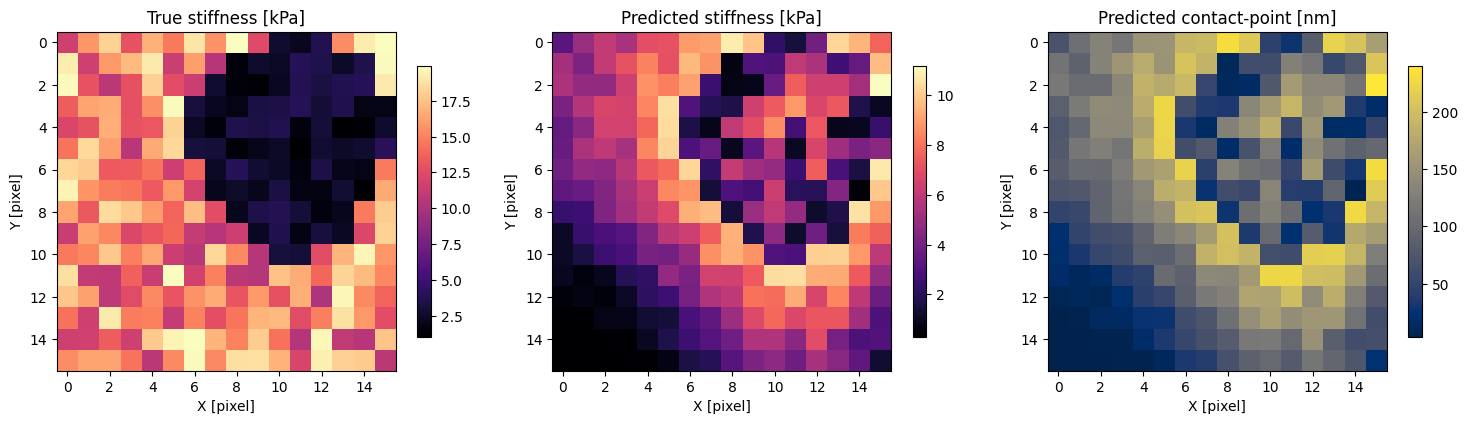

Mean test (stiffness): 0.9674156308174133
Mean contact-point MAE [nm]: 11878.0341796875


In [65]:
prediction_output = predict_curvewise(
    model=trained_model,
    curve_inputs=test_flat["curve_inputs"],
    batch_size=model_config.batch_size,
    device=device,
    predict_contact_point=model_config.predict_contact_point,
)

predicted_stiffness_maps_kpa = prediction_output["stiffness_predictions_kpa"].reshape(
    test_collection["stiffness_maps_kpa"].shape
)

predicted_contact_point_maps_nm = None
if model_config.predict_contact_point:
    predicted_contact_point_maps_nm = prediction_output["cp_predictions_nm"].reshape(
        test_collection["contact_point_maps_nm"].shape
    )

sample_to_display = model_config.default_sample_to_display
n_panels = 3 if model_config.predict_contact_point else 2
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))
axes = np.atleast_1d(axes)

im_true = axes[0].imshow(
    test_collection["stiffness_maps_kpa"][sample_to_display], cmap="magma"
)
axes[0].set_title("True stiffness [kPa]")
axes[0].set_xlabel("X [pixel]")
axes[0].set_ylabel("Y [pixel]")
plt.colorbar(im_true, ax=axes[0], shrink=0.8)

im_pred = axes[1].imshow(predicted_stiffness_maps_kpa[sample_to_display], cmap="magma")
axes[1].set_title("Predicted stiffness [kPa]")
axes[1].set_xlabel("X [pixel]")
axes[1].set_ylabel("Y [pixel]")
plt.colorbar(im_pred, ax=axes[1], shrink=0.8)

if model_config.predict_contact_point:
    im_cp = axes[2].imshow(
        predicted_contact_point_maps_nm[sample_to_display], cmap="cividis"
    )
    axes[2].set_title("Predicted contact-point [nm]")
    axes[2].set_xlabel("X [pixel]")
    axes[2].set_ylabel("Y [pixel]")
    plt.colorbar(im_cp, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

ape = np.abs(
    predicted_stiffness_maps_kpa - test_collection["stiffness_maps_kpa"]
) / np.clip(test_collection["stiffness_maps_kpa"], 1e-6, None)
print("Mean test (stiffness):", float(np.mean(ape)))

if model_config.predict_contact_point:
    cp_mae_nm = np.mean(
        np.abs(predicted_contact_point_maps_nm - test_collection["contact_point_maps_nm"])
    )
    print("Mean contact-point MAE [nm]:", float(cp_mae_nm))


## 17. Clickable stiffness-map viewer


In [66]:
# from google.colab import output
# output.enable_custom_widget_manager()
from IPython.display import display

try:
    import anywidget
    import ipywidgets as widgets
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("Plotly FigureWidget is available.")
except Exception as error:
    widgets = go = None
    PLOTLY_AVAILABLE = False
    print("Interactive viewer unavailable. Install anywidget, ipywidgets, and plotly.")
    print(f"Error: {error}")


def show_curve_for_pixel(sample_index, row_index, col_index):
    """Static fallback: plot the force curve for one pixel."""
    disp_um = test_collection["displacement_axis_um"]
    curve_nN = test_collection["measured_force_curves_nN"][sample_index, row_index, col_index]
    n = disp_um.shape[0] // 2
    true_kpa = test_collection["stiffness_maps_kpa"][sample_index, row_index, col_index]
    pred_kpa = predicted_stiffness_maps_kpa[sample_index, row_index, col_index]
    title = (
        f"Sample {sample_index}, pixel ({row_index}, {col_index}) | "
        f"true = {true_kpa:.2f} kPa | pred = {pred_kpa:.2f} kPa"
    )
    if model_config.predict_contact_point and predicted_contact_point_maps_nm is not None:
        cp_true = test_collection["contact_point_maps_nm"][sample_index, row_index, col_index]
        cp_pred = predicted_contact_point_maps_nm[sample_index, row_index, col_index]
        title += f" | cp true = {cp_true:.1f} nm | cp pred = {cp_pred:.1f} nm"
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(disp_um[:n], curve_nN[:n], label="Approach")
    ax.plot(disp_um[n:], curve_nN[n:], label="Retract")
    ax.set_xlabel("Displacement [µm]")
    ax.set_ylabel("Measured force [nN]")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


def display_clickable_stiffness_map(sample_index=0):
    """Display a clickable predicted stiffness map linked to a force-curve panel."""
    if not PLOTLY_AVAILABLE:
        print("Interactive viewer not available. Using static fallback.")
        show_curve_for_pixel(sample_index, 0, 0)
        return

    pred_map = predicted_stiffness_maps_kpa[sample_index]
    true_map = test_collection["stiffness_maps_kpa"][sample_index]
    curves_nN = test_collection["measured_force_curves_nN"][sample_index]
    disp_um = test_collection["displacement_axis_um"]
    n = disp_um.shape[0] // 2
    cp_true_map = (
        test_collection["contact_point_maps_nm"][sample_index]
        if model_config.predict_contact_point else None
    )
    cp_pred_map = (
        predicted_contact_point_maps_nm[sample_index]
        if model_config.predict_contact_point and predicted_contact_point_maps_nm is not None
        else None
    )

    heatmap_fig = go.FigureWidget(data=[go.Heatmap(
        z=pred_map,
        colorscale="Viridis",
        colorbar={"title": "kPa", "thickness": 15},
        hovertemplate="x=%{x}<br>y=%{y}<br>pred=%{z:.2f} kPa<extra></extra>",
    )])
    heatmap_fig.update_layout(
        title={"text": f"Map S{sample_index}", "y":0.98, "x":0.5, "xanchor": "center", "yanchor": "top"},
        xaxis_title="X", yaxis_title="Y",
        width=350, height=350,
        margin=dict(l=40, r=10, t=40, b=40)
    )
    heatmap_fig.update_yaxes(autorange="reversed")

    curve_fig = go.FigureWidget(data=[
        go.Scatter(name="Approach", mode="lines"),
        go.Scatter(name="Retracty", mode="lines"),
    ])
    curve_fig.update_layout(
        title={"text": "Select a pixel", "y":0.98, "x":0.5, "xanchor": "center", "yanchor": "top", "font": {"size": 12}},
        xaxis_title="Disp [µm]", yaxis_title="F [nN]",
        width=450, height=350,
        margin=dict(l=40, r=10, t=60, b=40),
        legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
    )

    def handle_click(trace, points, selector):
        if not points.xs:
            return
        c, r = int(points.xs[0]), int(points.ys[0])
        title = (
            f"Pixel({r},{c}) | True:{true_map[r, c]:.1f} | Predicted:{pred_map[r, c]:.1f} kPa"
        )
        if cp_true_map is not None and cp_pred_map is not None:
            title += f"<br>ContactPoint True:{cp_true_map[r, c]:.0f} | Predicted:{cp_pred_map[r, c]:.0f} nm"
        with curve_fig.batch_update():
            curve_fig.data[0].x = disp_um[:n]
            curve_fig.data[0].y = curves_nN[r, c, :n]
            curve_fig.data[1].x = disp_um[n:]
            curve_fig.data[1].y = curves_nN[r, c, n:]
            curve_fig.layout.title.text = title

    heatmap_fig.data[0].on_click(handle_click)
    display(widgets.HBox([heatmap_fig, curve_fig]))

display_clickable_stiffness_map(sample_index=model_config.default_sample_to_display)

Plotly FigureWidget is available.


    'data': [{'colorbar': {'thickness': 15, 'title': {'text': 'kPa'}},
         …